In [30]:
from jax.scipy.stats import norm, poisson
import jax.numpy as jnp
import jax
import matplotlib.pyplot as plt

from algorithms.pmmh import pmmh,multi_chain_pmmh
from algorithms.smc import particle_filter
from time import perf_counter
import seaborn as sb

from utilities.helpers import (
    autocorrelation,
    auto_window,
    autocorr_new,
    effective_sample_size,
)

is_accelerator = jax.devices()[0].platform != "cpu"
print(f"Using Accelerator: {is_accelerator}")

Using Accelerator: True


In [31]:
def model(x0, theta, key, t_range):
    delta_t = t_range[1] - t_range[0]

    gamma, xi, alpha, eta, damping, log_mean, log_std = theta
    log_beta_damping = damping
    log_beta_mean = log_mean
    log_beta_standard_deviation = log_std

    A = jnp.exp(-log_beta_damping * delta_t)
    M = log_beta_mean * (jnp.exp(-log_beta_damping * delta_t) - 1)
    C = log_beta_standard_deviation * jnp.sqrt(
        1 - jnp.exp(-2 * log_beta_damping * delta_t)
    )

    def tau_step(state, i):
        prev_x, prev_key = state
        S, I, H, R, log_beta = prev_x

        N = S + I + R + H

        update_key, next_key = jax.random.split(prev_key, 2)
        update_keys = jax.random.split(update_key, 6)

        log_beta = A * log_beta - M + C * jax.random.normal(update_keys[0])

        new_S = jax.random.poisson(update_keys[1], xi * R * delta_t)

        new_I = jax.random.poisson(
            update_keys[2], (jnp.exp(log_beta) * S * I) / N * delta_t
        )
        new_IH = jax.random.poisson(update_keys[3], alpha * gamma * I * delta_t)
        new_HR = jax.random.poisson(update_keys[4], eta * H * delta_t)
        new_IR = jax.random.poisson(update_keys[5], alpha * (1 - gamma) * I * delta_t)

        S = jnp.maximum(0.0, S + new_S - new_I)
        I = jnp.maximum(0.0, I + new_I - (new_IH + new_IR))
        H = jnp.maximum(0.0, H + new_IH - new_HR)
        R = jnp.maximum(0.0, R + new_HR + new_IR - new_S)

        return (jnp.array([S, I, H, R, log_beta]), next_key), jnp.array(
            [S, I, H, R, log_beta]
        )

    _, loop_val = jax.lax.scan(
        tau_step,
        init=(x0, key),
        xs=t_range[1:],
    )

    return jnp.concatenate((x0[jnp.newaxis, :], loop_val))

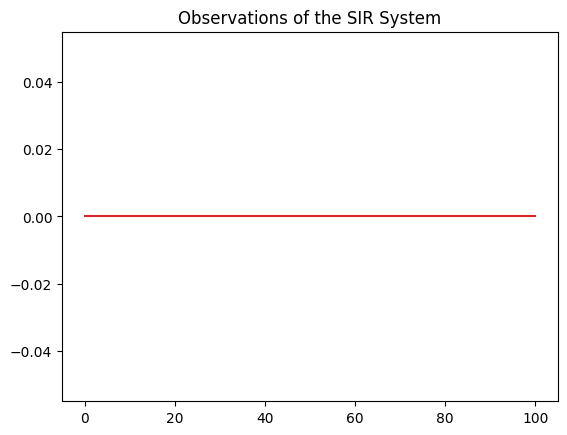

In [39]:
theta = (1/1000, 1 / 90, 1 / 7, 1 / 7, 1 / 35, jnp.log(0.35), 0.2)
delta_t = 1.0
days = 100
rng_key = jax.random.key(0)
t_range = jnp.arange(0, days + delta_t, delta_t)

num_models = 1_000
keys = jax.random.split(rng_key, num_models)

SIR_init_key, rng_key = jax.random.split(rng_key)
beta_init_key, rng_key = jax.random.split(rng_key)
I_x0 = jax.random.randint(SIR_init_key, minval=0, maxval=20, shape=(num_models,))

x0 = jnp.full(shape=(num_models, 4), fill_value=jnp.array([1000, 0, 0, 0]))

x0 = x0.at[:, 0].set(x0[:, 0] - I_x0)
x0 = x0.at[:, 1].set(x0[:, 1] + I_x0)

beta_x0 = jax.random.uniform(beta_init_key, shape=(num_models,), minval=0.1, maxval=0.5)

beta_x0 = beta_x0[..., jnp.newaxis]

x0 = jnp.concatenate((x0, jnp.log(beta_x0)), axis=-1)

full_state = jax.vmap(model, in_axes=(0, None, 0, None))(x0, theta, keys, t_range)

observations = full_state[0, :, 2]

plt.title("Observations of the SIR System")
plt.plot(
    t_range,
    observations.T,
    color="tab:red",
)
plt.show()

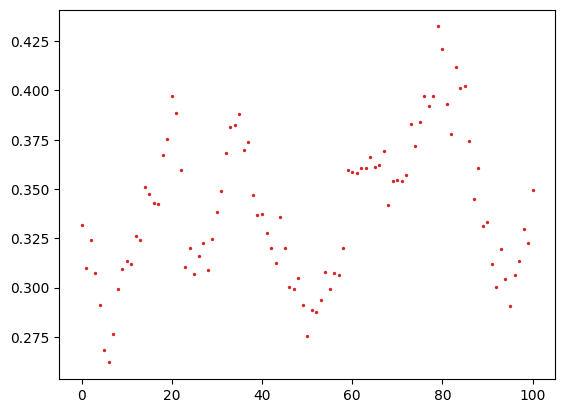

In [33]:
plt.scatter(
        t_range,
        jnp.exp(full_state[0,:,-1]).T,
        color="tab:red",
        s = 2.0,
        zorder=100
    )

In [34]:
def likelihood(particles,observation): 
    return jax.scipy.stats.poisson.logpmf(observation, mu = particles[:,1])

In [35]:
def f(theta, key, observations):
    num_particles = 100
    key, init_key = jax.random.split(key)
    I_x0 = jax.random.randint(init_key, minval=0, maxval=20, shape=(num_particles,))

    particles = jnp.full(shape=(num_particles, 4), fill_value=jnp.array([1000., 0., 0., 0.]))
    beta_x0 = jax.random.uniform(beta_init_key, shape=(num_particles,), minval=0.1, maxval=0.5)

    particles = particles.at[:, 0].set(particles[:, 0] - I_x0)
    particles = particles.at[:, 1].set(particles[:, 1] + I_x0)

    particles = particles.at[:,-1].set(jnp.log(beta_x0))

    particles, weights = particle_filter(
        model,
        observations,
        particles,
        key,
        likelihood,
        theta,
        jnp.linspace(0, 1, 2),
    )

    return jnp.sum(jnp.log(jnp.mean(weights, axis=0)))

In [36]:
def log_p(theta, key):
    # gamma: Uniform between 0.05 and 0.2
    p0_loc = 0.05
    p0_scale = 0.2 - 0.05

    # xi: Uniform between 1/365 and 1/30
    p1_loc = 1.0 / 365.0
    p1_scale = (1.0 / 30.0) - (1.0 / 365.0)
    
    # lambda: Uniform between 1/100 and 1/7
    p2_loc = 1.0 / 100.0
    p2_scale = (1.0 / 7.0) - (1.0 / 100.0)
    
    # mu: Uniform between -1.5 and -0.75
    p3_loc = -1.5
    p3_scale = (-0.75 - (- 1.5))
    
    # sigma: Uniform between 0.05 and 0.5
    p4_loc = 0.05
    p4_scale = 0.5 - 0.05

    return (
        f(theta, key, observations)
        + jax.scipy.stats.uniform.logpdf(theta[0], loc=p0_loc, scale=p0_scale)
        + jax.scipy.stats.uniform.logpdf(theta[1], loc=p1_loc, scale=p1_scale)
        + jax.scipy.stats.uniform.logpdf(theta[2], loc=p2_loc, scale=p2_scale)
        + jax.scipy.stats.uniform.logpdf(theta[3], loc=p3_loc, scale=p3_scale)
        + jax.scipy.stats.uniform.logpdf(theta[4], loc=p4_loc, scale=p4_scale)
    )


In [37]:
iterations = 10_000
burnin = 10_000
pmmh_key, rng_key = jax.random.split(rng_key)
num_chains = 1
xi_key, gamma_key, damping_key, log_mean_key, log_vol_key, rng_key = jax.random.split(
    rng_key, 6
)
theta0 = jnp.array(
    [
        jax.random.uniform(gamma_key, minval=0.05, maxval=0.2, shape=num_chains),
        jax.random.uniform(xi_key, minval=1 / 365, maxval=1 / 30, shape=num_chains),
        jax.random.uniform(damping_key, minval=1 / 100, maxval=1 / 7, shape=num_chains),
        jax.random.uniform(log_mean_key, minval=-1.5, maxval=-0.75, shape=num_chains),
        jax.random.uniform(log_vol_key, minval=0.05, maxval=0.5, shape=num_chains),
    ]
).T

t0 = perf_counter()
samples, lnprob = multi_chain_pmmh(
    f=log_p,
    M=iterations,
    burnin=burnin,
    theta0=theta0,
    adaptive=True,
    key=pmmh_key,
    cov_matrix=0.1 * jnp.eye(len(theta)),
    num_chains=num_chains,
)
t1 = perf_counter()

ValueError: not enough values to unpack (expected 7, got 5)

Runtime is 133.11204423196614 seconds.
Effective sample size: [ 43.520588  133.77786    35.643555   11.3505125  87.7546   ]
Integrated autocorrelation: [22.97763    7.4750786 28.055563  88.10175   11.395414 ]


/tmp/ipykernel_3449567/2670115413.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sb.distplot(samples[:, :, i])


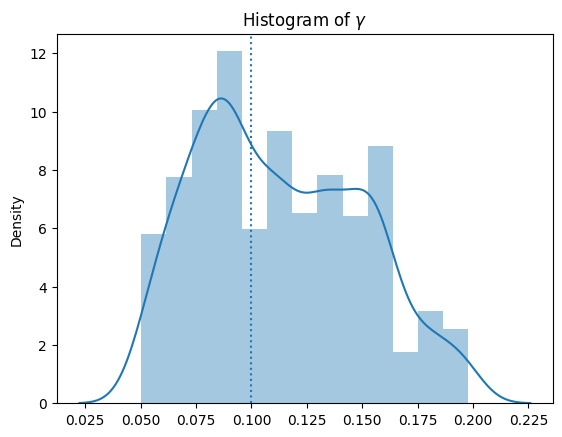

/tmp/ipykernel_3449567/2670115413.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sb.distplot(samples[:, :, i])


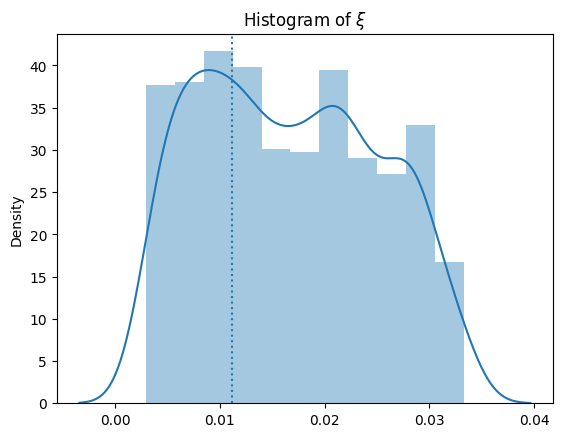

/tmp/ipykernel_3449567/2670115413.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sb.distplot(samples[:, :, i])


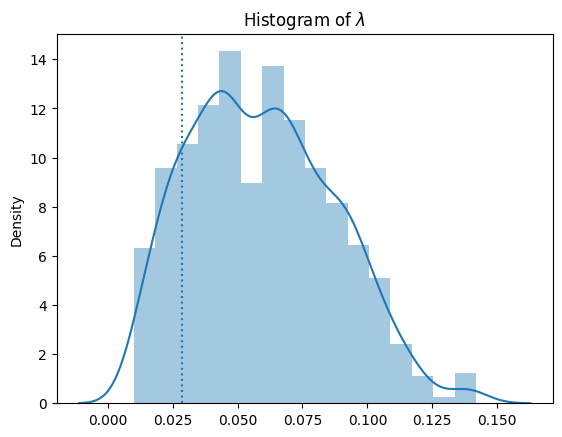

/tmp/ipykernel_3449567/2670115413.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sb.distplot(samples[:, :, i])


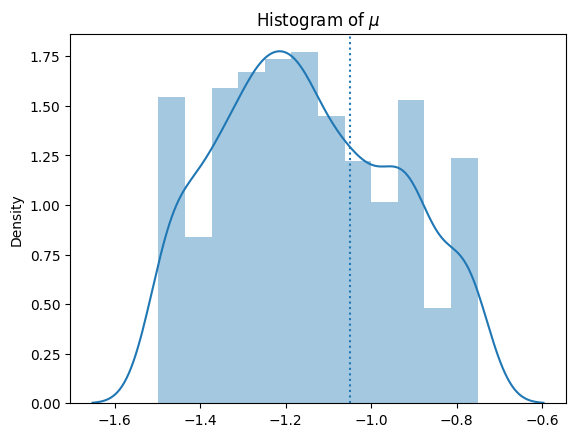

/tmp/ipykernel_3449567/2670115413.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sb.distplot(samples[:, :, i])


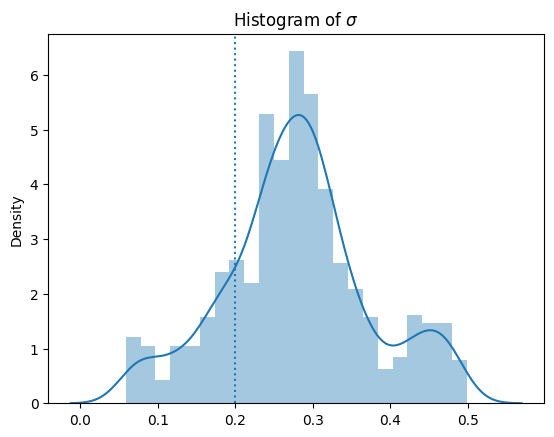

In [ ]:
print(f"Runtime is {t1 - t0} seconds.")
print(f"Effective sample size: {effective_sample_size(samples)}")
print(f"Integrated autocorrelation: {autocorr_new(samples)}")
theta_names = ["$\\gamma$", "$\\xi$","$\\alpha$","$\\eta$","$\\lambda$","$\\mu$","$\\sigma$"]

for i, name in enumerate(theta_names):
    plt.title(f"Histogram of {name}")
    sb.distplot(samples[:, :, i])
    plt.axvline(theta[i],ls = 'dotted')
    plt.show()